# Regresión aplicada a datos de calidad del aire

## Descripción

En este trabajo se desarrolla un problema de regresión sobre un conjunto de datos de calidad del aire recopilado mediante sensores químicos.

El análisis incluye la preparación de los datos, la exploración de variables, la construcción de modelos de regresión lineal simple y múltiple, y la comparación con árboles de decisión para regresión.

## Objetivos

* Realizar un análisis exploratorio de los datos.
* Preparar y transformar las variables.
* Aplicar regresión lineal simple.
* Aplicar regresión lineal múltiple.
* Aplicar árboles de decisión para regresión.
* Evaluar y comparar los modelos mediante distintas métricas.
* Analizar posibles problemas de sobreajuste.

## Dataset

Air Quality Dataset, disponible en el repositorio UCI Machine Learning:

https://archive.ics.uci.edu/dataset/360/air+quality

El conjunto contiene mediciones horarias de sensores químicos registradas en una zona urbana italiana entre marzo de 2004 y febrero de 2005.


## Análisis exploratorio de los datos

In [1]:
import statistics

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

filename = "AirQualityUCI.csv"

data = pd.read_csv(
    filename,
    delimiter=";",
    encoding="latin1"
)

df = data.copy()

In [2]:
## ¿cuántas instancias tiene el dataset?
num_corpus = len(data)

print(f"El DataFrame contiene {num_corpus} instancias.")

"""
Al llegar al apartado 3, comprobamos que el DATAFRAME, tiene varías líneas vacías. Vamos a hacer la limpieza de esas líneas en este apartado.
De este modo obtenemos realmente el número de instancias reales de nuestro corpus.
"""
df.dropna(axis=0, how='all', inplace=True)

num_corpus = len(df)

print(f"El DataFrame corregido contiene {num_corpus} instancias.")

El DataFrame contiene 9471 instancias.
El DataFrame corregido contiene 9357 instancias.


El DataFrame contiene 9357 instancias

In [3]:
## ¿cuál es el tipo de datos de cada una de las columnas?
#Voy a ver primero qué datos recoge nuestro dataframe
columnas=data.columns
print(columnas)
#Ahora vere que tipo de datos tiene cada columna
tipos_de_datos = data.dtypes
print(tipos_de_datos)

#Analizando el dataframe, compruebo que todos los datos deberían ser numéricos, a excepción del día y la hora, que son objetos. Limpiamos el dataframe.

# Voy a convertir las columnas numéricas a float, reemplazando comas por puntos
columnas_numericas = df.columns.drop(['Date', 'Time'])
for columna in columnas_numericas:
    # Asegurarse de que la columna sea tratada como cadena de texto
    df[columna] = df[columna].astype(str)
    # Reemplazar comas por puntos
    df[columna] = df[columna].str.replace(',', '.')
    # Convertir a float
    df[columna] = pd.to_numeric(df[columna], errors='coerce')

# Reemplazar valores faltantes (-200) por NaN
df.replace(to_replace=-200.0, value=pd.NA, inplace=True)

for columna in columnas_numericas:
    df[columna] = pd.to_numeric(df[columna], errors='coerce')

# Eliminar columnas extra que no existen
df.dropna(axis=1, how='all', inplace=True)


# Verificar los tipos de datos después de la limpieza
print("Tipos de datos después de la limpieza:")
tipos_de_datos = df.dtypes
print(tipos_de_datos)

columnas=df.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16'],
      dtype='str')
Date                 str
Time                 str
CO(GT)               str
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)             str
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                    str
RH                   str
AH                   str
Unnamed: 15      float64
Unnamed: 16      float64
dtype: object
Tipos de datos después de la limpieza:
Date                 str
Time                 str
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(

Tipos de datos después de la limpieza:
- Date:              object 
- Time:              object
- CO(GT):           float64
- PT08.S1(CO):      float64
- NMHC(GT):         float64
- C6H6(GT):         float64
- PT08.S2(NMHC):    float64
- NOx(GT):          float64
- PT08.S3(NOx):     float64
- NO2(GT):          float64
- PT08.S4(NO2):     float64
- PT08.S5(O3):      float64
- T:                float64
- RH:               float64
- AH:               float64

## ¿cuántas columnas categóricas hay? ¿y cuántas continuas?


Tenemos por una parte, las variables que nos muestran parámetros del aire, que se trataría de variables continuas.

Por otra parte, las variables temperatura y las dos de humedad, serían también variables continuas. 

Esto es porque pueden tomar cualquier valor dentro de un rango.

Respecto a la fecha y la hora, serían variables categóricas.

Hay por tanto, 13 columnas continuas y 2 categóricas.

## ¿existen valores nulos en el dataset?


Teníamos valores traducidos como "-200". Estos valores eran valores faltantes, y por tanto se han considerado nulos.

## ¿cuál es la variable respuesta?¿de qué tipo es?

Hay varias diferentes opciones como variable respuesta. Comprobamos a priori 10 diferentes columnas de concentración de gases, además también se mide la temperatura y la humedad, en porcentaje y en g/m3.
El objetivo de recoger los datos es obtener la CALIDAD DEL AIRE. Por tanto, se deduce que la variable respuesta debería ser una concentración de gases.
Se toma como variable respuesta, el NO2(GT). Se trata de un contaminante significativo emitido por los vehículos, lo cual lo hace relevante en este contexto en el que nos encontramos con una carretera.


Los estadísticos de CO son:
 La media de CO es 2.15
 El mínimo de CO es 0.1
 El quantil 1 de CO es 1.1
 La mediana de CO es 1.8
 El quantil 3 de CO es 2.9
 El máximo de CO es 11.9
 La moda de CO es 1.0
 La desviación estandar de CO es 1.45
 La asimetría de CO es 1.37
 El curtosis de CO es 2.67

Los estadísticos de NOx son:
 La media de NOx es 246.9
 El mínimo de NOx es 2.0
 El quantil 1 de NOx es 98.0
 La mediana de NOx es 180.0
 El quantil 3 de NOx es 326.0
 El máximo de NOx es 1479.0
 La moda de NOx es 89.0
 La desviación estandar de NOx es 212.98
 La asimetría de NOx es 1.72
 El curtosis de NOx es 3.4

Los estadísticos de NO2 son:
 La media de NO2 es 113.09
 El mínimo de NO2 es 2.0
 El quantil 1 de NO2 es 78.0
 La mediana de NO2 es 109.0
 El quantil 3 de NO2 es 142.0
 El máximo de NO2 es 340.0
 La moda de NO2 es 97.0
 La desviación estandar de NO2 es 48.37
 La asimetría de NO2 es 0.62
 El curtosis de NO2 es 0.47



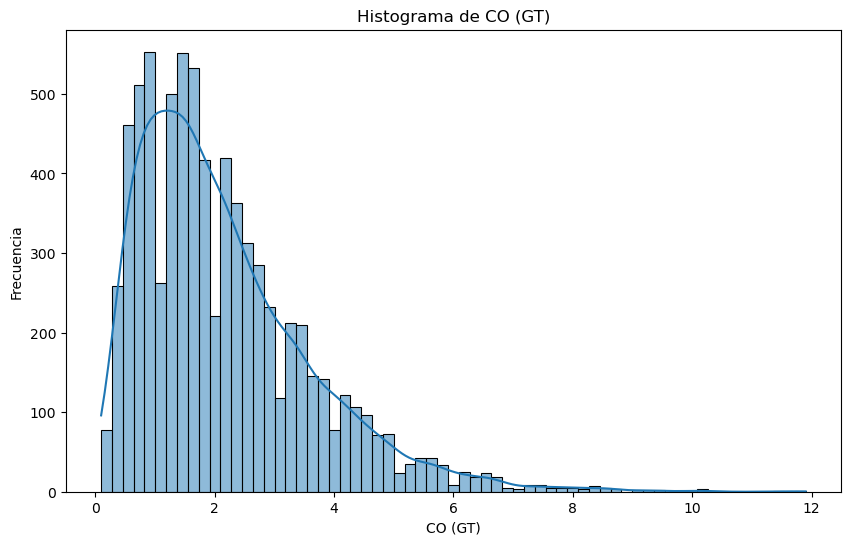

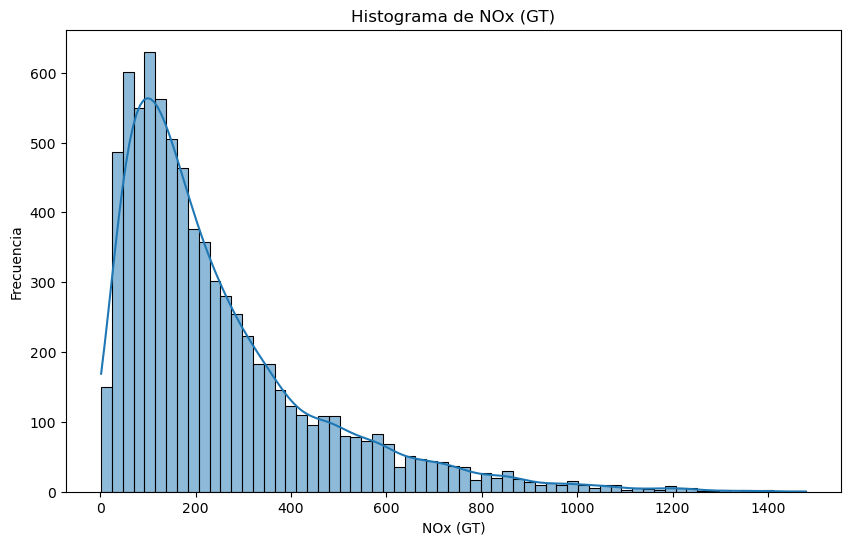

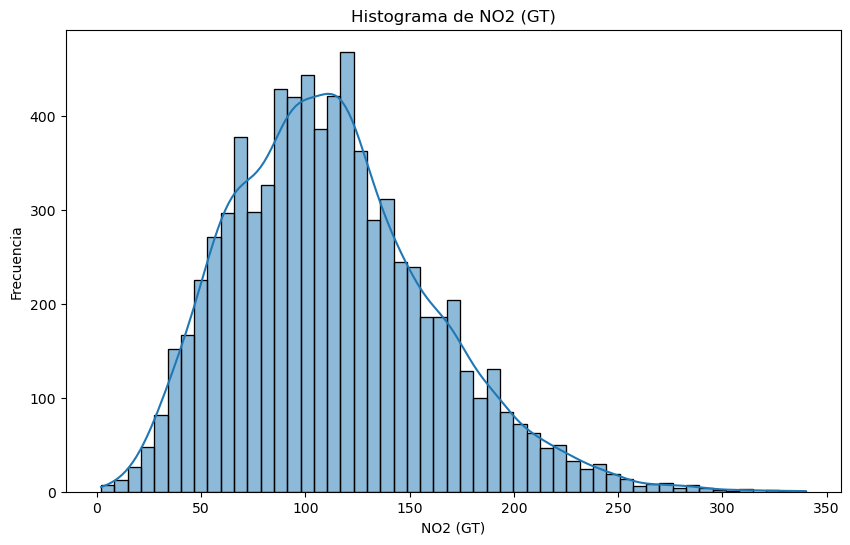

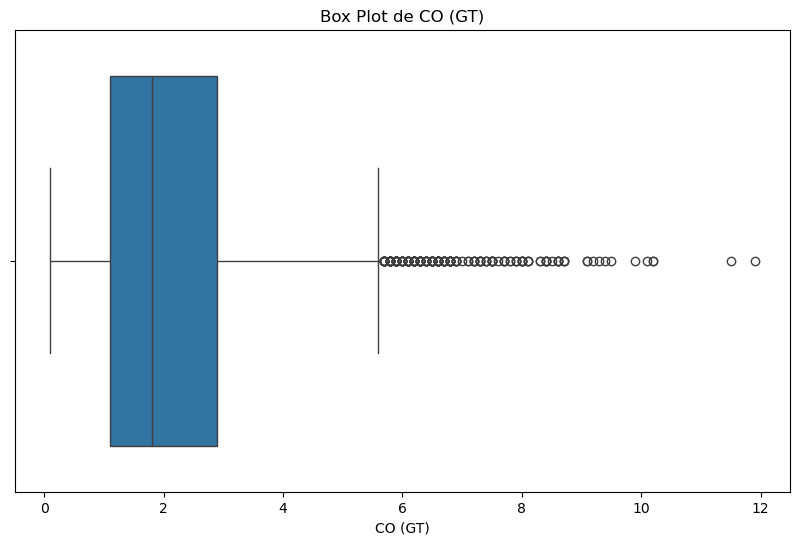

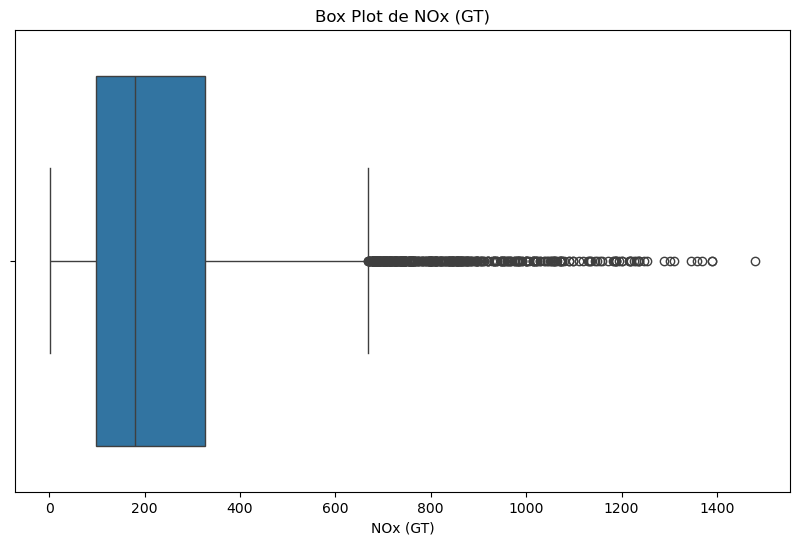

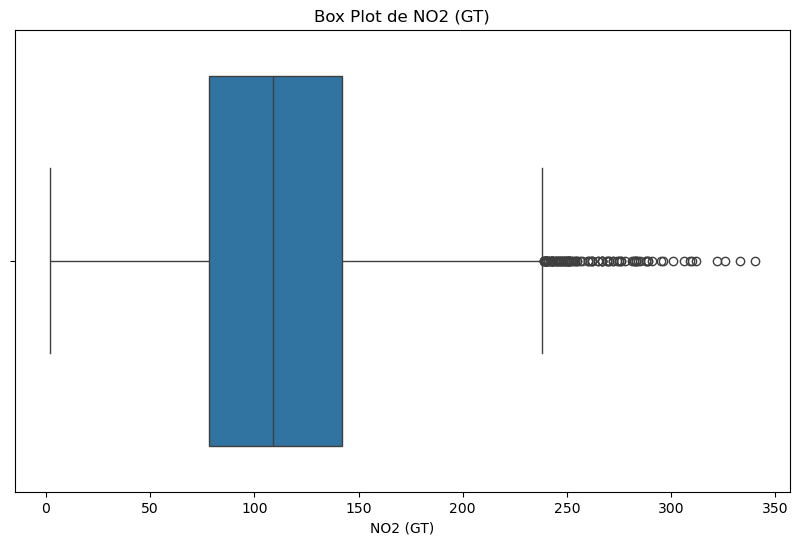

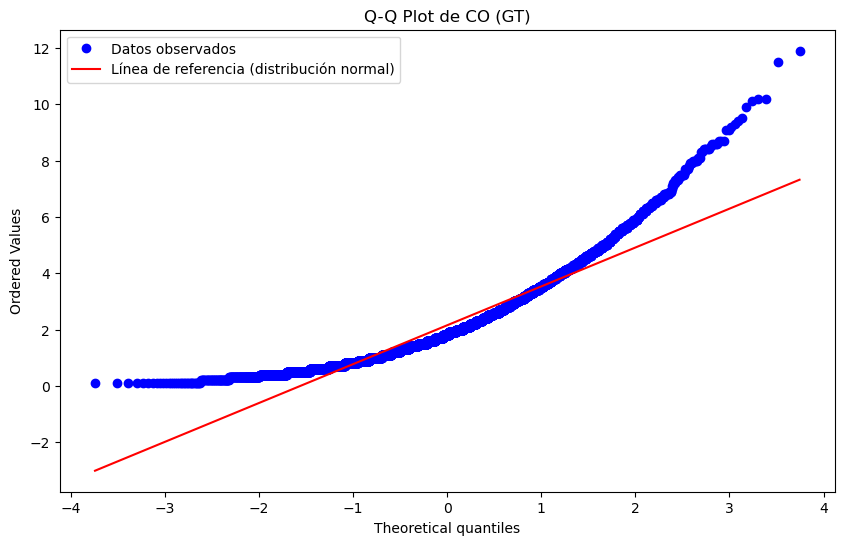

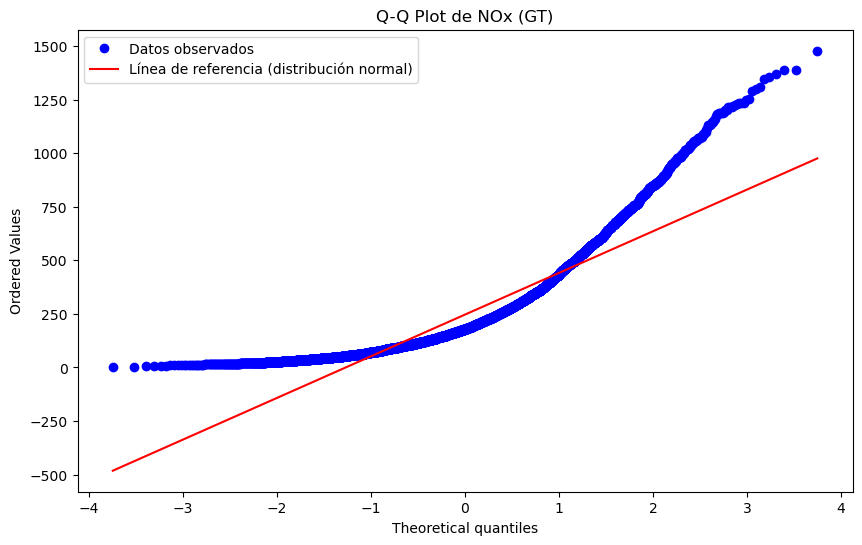

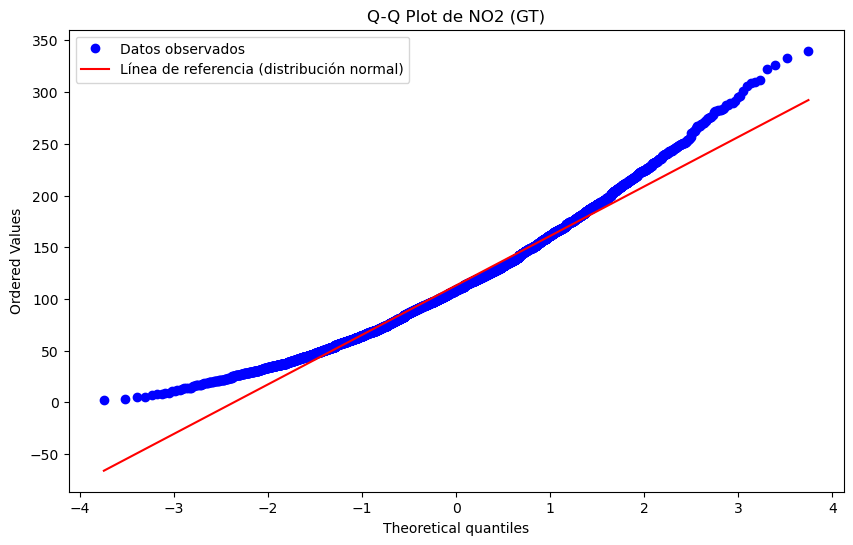

In [4]:
## Si te fijas en los estadísticos del dataset, ¿cómo es la distribución de las variables, CO, NOx y NO2? 

# Variable CO

recuento_CO, media_CO, std_CO, min_CO, q1_CO, median_CO,q3_CO, max_CO=df['CO(GT)'].describe().round(2)

moda_CO = statistics.mode(df['CO(GT)'])
asimetria_CO=df['CO(GT)'].skew().round(2)
curtosis_CO=df['CO(GT)'].kurt().round(2)


print('Los estadísticos de CO son:\n',
      f'La media de CO es {media_CO}\n', 
      f'El mínimo de CO es {min_CO}\n',
      f'El quantil 1 de CO es {q1_CO}\n',
      f'La mediana de CO es {median_CO}\n',
      f'El quantil 3 de CO es {q3_CO}\n',
      f'El máximo de CO es {max_CO}\n',
      f'La moda de CO es {moda_CO}\n',
      f'La desviación estandar de CO es {std_CO}\n',
      f'La asimetría de CO es {asimetria_CO}\n',
      f'El curtosis de CO es {curtosis_CO}\n'
      )

# Variable NOx

recuento_NOx, media_NOx, std_NOx, min_NOx, q1_NOx, median_NOx,q3_NOx, max_NOx=df['NOx(GT)'].describe().round(2)

moda_NOx = statistics.mode(df['NOx(GT)'])
asimetria_NOx=df['NOx(GT)'].skew().round(2)
curtosis_NOx=df['NOx(GT)'].kurt().round(2)


print('Los estadísticos de NOx son:\n',
      f'La media de NOx es {media_NOx}\n', 
      f'El mínimo de NOx es {min_NOx}\n',
      f'El quantil 1 de NOx es {q1_NOx}\n',
      f'La mediana de NOx es {median_NOx}\n',
      f'El quantil 3 de NOx es {q3_NOx}\n',
      f'El máximo de NOx es {max_NOx}\n',
      f'La moda de NOx es {moda_NOx}\n',
      f'La desviación estandar de NOx es {std_NOx}\n',
      f'La asimetría de NOx es {asimetria_NOx}\n',
      f'El curtosis de NOx es {curtosis_NOx}\n'
      )

# Variable NO2

recuento_NO2, media_NO2, std_NO2, min_NO2, q1_NO2, median_NO2,q3_NO2, max_NO2=df['NO2(GT)'].describe().round(2)

moda_NO2 = statistics.mode(df['NO2(GT)'])
asimetria_NO2=df['NO2(GT)'].skew().round(2)
curtosis_NO2=df['NO2(GT)'].kurt().round(2)


print('Los estadísticos de NO2 son:\n',
      f'La media de NO2 es {media_NO2}\n', 
      f'El mínimo de NO2 es {min_NO2}\n',
      f'El quantil 1 de NO2 es {q1_NO2}\n',
      f'La mediana de NO2 es {median_NO2}\n',
      f'El quantil 3 de NO2 es {q3_NO2}\n',
      f'El máximo de NO2 es {max_NO2}\n',
      f'La moda de NO2 es {moda_NO2}\n',
      f'La desviación estandar de NO2 es {std_NO2}\n',
      f'La asimetría de NO2 es {asimetria_NO2}\n',
      f'El curtosis de NO2 es {curtosis_NO2}\n'
      )


#HISTOGRAMAS
#CO
plt.figure(figsize=(10, 6))
sns.histplot(df['CO(GT)'].dropna(), kde=True)
plt.title('Histograma de CO (GT)')
plt.xlabel('CO (GT)')
plt.ylabel('Frecuencia')
plt.show()

#NOx
plt.figure(figsize=(10, 6))
sns.histplot(df['NOx(GT)'].dropna(), kde=True)
plt.title('Histograma de NOx (GT)')
plt.xlabel('NOx (GT)')
plt.ylabel('Frecuencia')
plt.show()

#NO2

plt.figure(figsize=(10, 6))
sns.histplot(df['NO2(GT)'].dropna(), kde=True)
plt.title('Histograma de NO2 (GT)')
plt.xlabel('NO2 (GT)')
plt.ylabel('Frecuencia')
plt.show()


# Diagrama de cajas
#CO
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['CO(GT)'].dropna())
plt.title('Box Plot de CO (GT)')
plt.xlabel('CO (GT)')
plt.show()
#NOx
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['NOx(GT)'].dropna())
plt.title('Box Plot de NOx (GT)')
plt.xlabel('NOx (GT)')
plt.show()
#NO2
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['NO2(GT)'].dropna())
plt.title('Box Plot de NO2 (GT)')
plt.xlabel('NO2 (GT)')
plt.show()

# Q-Q Plot
import scipy.stats as stats
#CO
plt.figure(figsize=(10, 6))
stats.probplot(df['CO(GT)'].dropna(), dist="norm", plot=plt)
plt.title('Q-Q Plot de CO (GT)')
plt.legend(['Datos observados','Línea de referencia (distribución normal)'])
plt.show()
#NOx
plt.figure(figsize=(10, 6))
stats.probplot(df['NOx(GT)'].dropna(), dist="norm", plot=plt)
plt.title('Q-Q Plot de NOx (GT)')
plt.legend(['Datos observados','Línea de referencia (distribución normal)'])
plt.show()
#NO2
plt.figure(figsize=(10, 6))
stats.probplot(df['NO2(GT)'].dropna(), dist="norm", plot=plt)
plt.title('Q-Q Plot de NO2 (GT)')
plt.legend(['Datos observados','Línea de referencia (distribución normal)'])
plt.show()


Conclusiones hasta el momento: Se explica la asimetría que hay hacia la derecha, esto es debido a que la mayoría de valores los tenemos en concentraciones bajas.
La asimetría se da, en las tres situaciones, por esos valores altos que probablemente indiquen la contaminación del aire.
Ocurre en las tres situaciones,y es más, si vemos los diagramas de cajas, en ambas tres situaciones hay valores que salen de la caja en la derecha.
De los tres, concretamente el N02 es aquel que tiene menos asimetría, menos valores fuera de la caja, y una distribución más normal. 

¿Estas variables muestran alguna distribución especial?¿Tienen datos faltantes?¿y datos anómalos?

Respecto a la distribución, no se ve una distribución en especial. El dióxido de nitrógeno si se asemeja a una distribución Normal.
En un terreno natural, se esperaría tener valores de distribución normal para las tres características. 
Esto deja de ocurrir aquí, teniendo asimetría hacia la derecha por la contaminación que produce el ser humano.
Se razona que tenemos la menor incidencia en el NO2, y es por ello que es la que sigue una distribución más constante.

Hemos visto que había datos faltantes, que estaban recogidos como "-200" (las tres)

Ambas tres tienen datos anómalos, como podemos comprobar en el diagrama de cajas. Creo que en este caso se trata de picos de tráfico. Pero de momento no podemos concluir más.

In [5]:
# Vamos a hacer un nuevo dataframe
# Vamos a pasar las dos primeras columnas a numéricas.
# También, para ver la correlación, vamos a cambiar los valores nulos por la media.

data_num = data.copy() #este dataframe pasaremos todo a numérico, incluidas las variables categóricas
data_num.dropna(axis=0, how='all', inplace=True)
data_num.dropna(axis=1, how='all', inplace=True)

# Convertir la columna Date a formato datetime
data_num['Date'] = pd.to_datetime(data_num['Date'], format='%d/%m/%Y')

# Normalizar la columna Date para que el primer día sea 1
data_num['Date'] = (data_num['Date'] - data_num['Date'].min()).dt.days + 1

# Convertir la columna Time a formato datetime y extraer la hora
data_num['Time'] = pd.to_datetime(data_num['Time'], format='%H.%M.%S').dt.hour + 1


# Voy a convertir las columnas numéricas a float, reemplazando comas por puntos
columnas_numericas = data_num.columns.drop(['Date', 'Time'])
for columna in columnas_numericas:
    # Asegurarse de que la columna sea tratada como cadena de texto
    data_num[columna] = data_num[columna].astype(str)
    # Reemplazar comas por puntos
    data_num[columna] = data_num[columna].str.replace(',', '.')
    # Convertir a float
    data_num[columna] = pd.to_numeric(data_num[columna], errors='coerce')

for col in data_num.columns:
    array = data_num[col]
    array.replace(-200, np.nan, inplace=True)    
    media = array.mean()    
    array.fillna(media, inplace = True)    
    data_num[col] = array

for columna in columnas_numericas:
    data_num[columna] = pd.to_numeric(data_num[columna], errors='coerce')
    


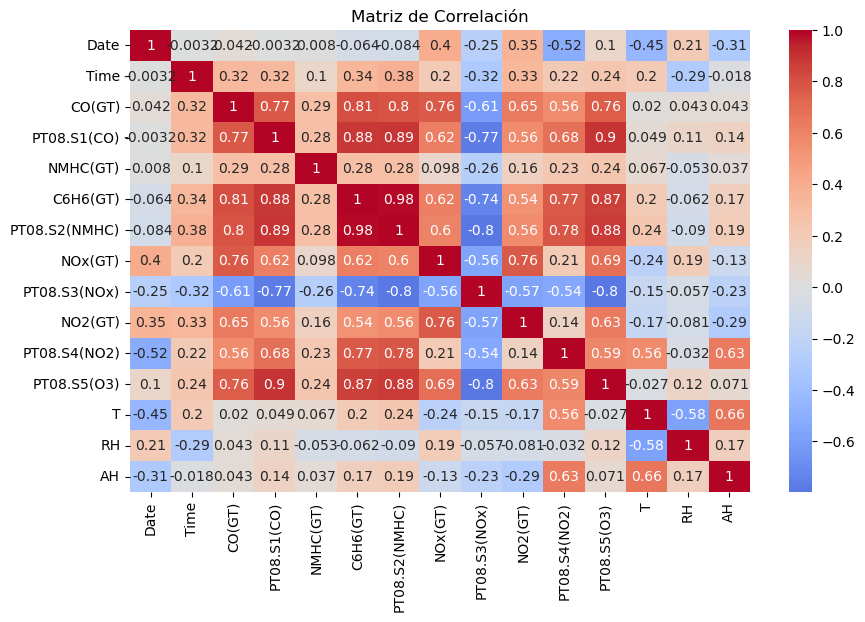

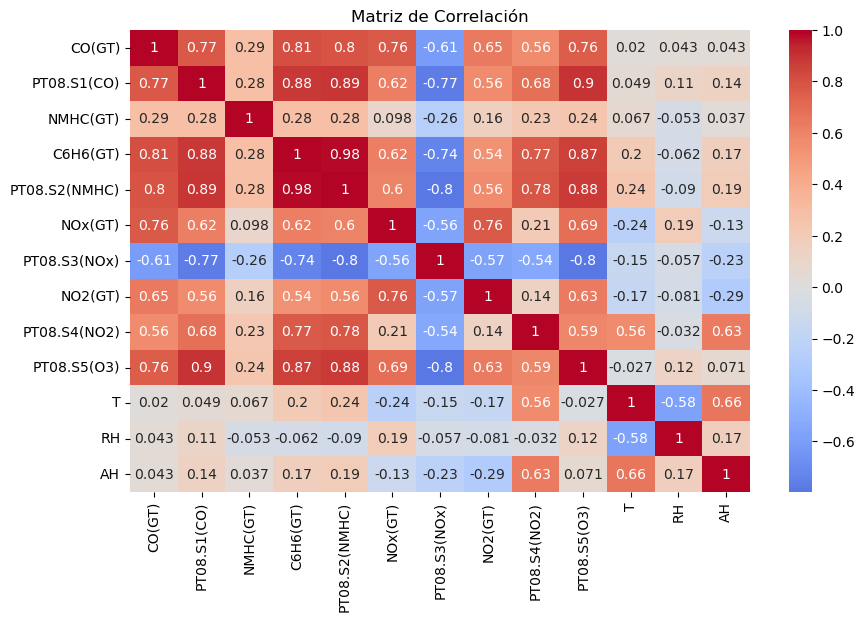

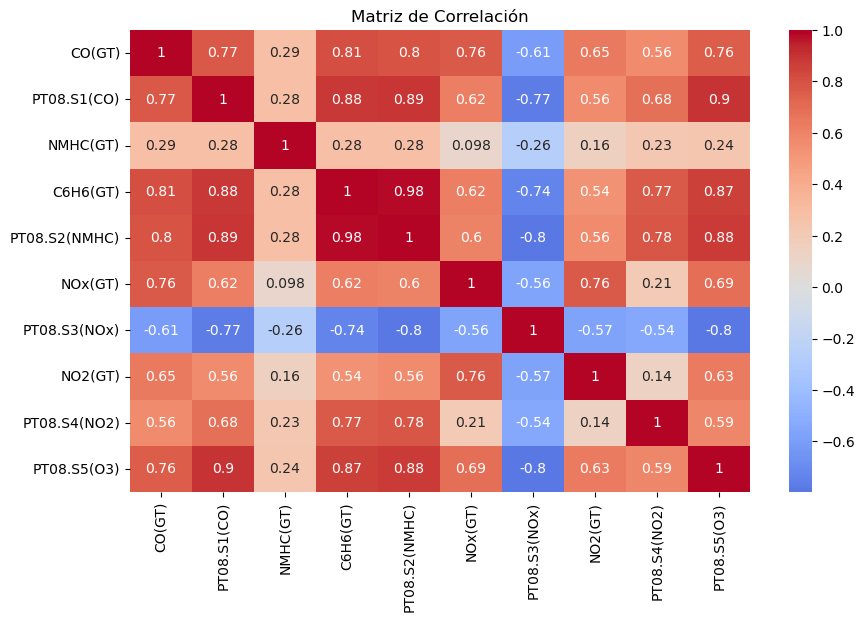

In [6]:
## ¿cómo son las correlaciones entre las variables del dataset?

# Voy a hacer tres matrices de correlación, una con todos los valores, otra sin las categóricas y otra solo con los de los contaminantes.
cont_temp_hum = data_num.drop(columns=['Date', 'Time'])
cont = data_num.drop(columns=['Date', 'Time', 'T', 'RH', 'AH'])


# Calcular la matriz de correlación
correlation_matrix_data = data_num.corr()
correlation_matrix = cont_temp_hum.corr()
correlation_matrix_cont = cont.corr()


# Crear un mapa de calor para la matriz de correlación (total)
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix_data, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

# Crear un mapa de calor para la matriz de correlación (sin quitar time,etc)
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

# Crear un mapa de calor para la matriz de correlación
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix_cont, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

En las tablas se recoge la correlación lineal para todas las variables a pares. Resulta curioso comentar la correlación casi perfecta entre el metano y el sensor 2.

In [7]:
## ¿qué tres variables son las más correlacionadas con la variable objetivo?

Vemos que las variables que más correlación tienen con la variable objetivo son el NOX(GT), el CO(GT) y el PT08.S5(O3)
Sorprende que una de las variables menos relacionada linealmente con la variable objetivo es la PT08.S4(NO2). Confunde que el sensor del dióxido de Nitrógeno sea el que menos correlación tenga con el dióxido de nitrógeno en GT.

In [8]:
## ¿existe alguna variable que no tenga correlación?

Vemos que el día y la hora, practicamente no tienen correlación con el resto de variables.
La humedad relativa tampoco tiene practicamente relación con las demás variables, sorprende que no la tenga con la humedad relativa.

El NMHC(GT) tampoco tiene casi correlación con el resto de variables.

En base al EDA realizado, ¿qué suposiciones se pueden hacer sobre los datos?¿qué conclusiones extraes para implementar el modelo predictivo?

Vemos que los sensores y los contaminantes tienen en general mucha correlación entre ellos, por lo que cualquier de ellos nos podría dar información de la calidad del aire.

### Regresión

Para llevar a cabo la tarea de regresión deseada se pretender hacer una comparativa de varios modelos. Unos usarán el algoritmo de regresión lineal, y otros realizarán la predicción haciendo uso de árboles de decisión.

Para los primeros modelos hay que usar el módulo https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html 

El algoritmo de Regresión Lineal necesita saber cuáles son las variables que va a tener en cuenta para realizar la estimación.

El primero modelo que se debe construir usará una regresión lineal simple. Para ello sigue los siguientes pasos.

Antes de empezar con la implementación de los modelos hace falta realizar una transformación de datos, escalarlos.

In [9]:
from sklearn.preprocessing import MinMaxScaler
from pandas import DataFrame
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer


scaler = StandardScaler()
model=LinearRegression()

Xy_train_test = data_num.copy()
Xy_train_test=Xy_train_test.drop(columns=['Date', 'Time']) #Además de ser categóricas, por lo que no tiene sentido estandarizarlas, tampoco tenían correlación.

columnas=Xy_train_test.columns
print(columnas)

# Aplicar la estandarización a los conjuntos de entrenamiento y prueba
Xy_train_test_scaled = pd.DataFrame(scaler.fit_transform(Xy_train_test), columns=Xy_train_test.columns)



Index(['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)',
       'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
       'T', 'RH', 'AH'],
      dtype='str')


In [10]:
# separar datos de entrenamiento y test

In [11]:
# Dividir los datos en conjuntos de entrenamiento y prueba
#Xy_train_test_scaled=Xy_train_test_scaled.dropna() #Me pensaba deshacer de todas las filas con variable NaN, para luego tener los mismos valores en los diferentes entrenamientos, pero salen pocos valores, así que de momento en el linear los sacamos despues
Xy_train, Xy_test = train_test_split(Xy_train_test_scaled, test_size=0.2, random_state=42)

print("X_train_scaled:\n", len(Xy_train))
print("X_test_scaled:\n", len(Xy_test))

X_train_scaled:
 7485
X_test_scaled:
 1872


In [12]:
# escoger la variable que a partir del EDA realizado, consideres que mejor va a realizar la predicción

La variable que seleccionamos es la NOx (GT) que era la variable con la que más correlación tenía NO2 (GT)

In [13]:
# Separar las características (X) y la variable respuesta (y)
Xy_train_1var=Xy_train[['NOx(GT)', 'NO2(GT)']]
Xy_train_1var = Xy_train_1var.dropna()
Xy_test_1var=Xy_test[['NOx(GT)', 'NO2(GT)']]
Xy_test_1var = Xy_test_1var.dropna()
print("X_train_scaled:\n", len(Xy_train_1var))
print("X_test_scaled:\n", len(Xy_test_1var))

X_train = Xy_train_1var['NOx(GT)'] #Cogemos la variable NOx, que es la que más correlación tenía
X_test = Xy_test_1var['NOx(GT)']
Y_train = Xy_train_1var['NO2(GT)']
Y_test = Xy_test_1var['NO2(GT)']

X_train = np.array(X_train).reshape(-1, 1)
X_test = np.array(X_test).reshape(-1,1)
"""
print(X_train)
print(type(X_train))
print(X_train.shape)
print(type(Y_train))
print(Y_train.shape)
"""

X_train_scaled:
 7485
X_test_scaled:
 1872


'\nprint(X_train)\nprint(type(X_train))\nprint(X_train.shape)\nprint(type(Y_train))\nprint(Y_train.shape)\n'

In [14]:
# entrena el modelo con los datos de entrenamiento

In [15]:
# Crear una instancia del modelo de regresión lineal
model = LinearRegression()

# Entrenar el modelo con los datos de entrenamiento
model.fit(X_train, Y_train)

# Hacer predicciones con los datos de prueba
Y_pred = model.predict(X_test)



In [16]:
# ¿cuáles son los valores aprendidos por el modelo para los parámetros?

In [17]:
# Obtener los valores aprendidos por el modelo para los parámetros
coeficientes_escalados = model.coef_.round(5)
intercepto_escalado = model.intercept_.round(5)

print("Coeficientes:", coeficientes_escalados)
print("Intercepto:", intercepto_escalado)

# Desescalar los coeficientes
coeficientes_originales = (coeficientes_escalados *scaler.scale_[7] / scaler.scale_[5]).round(5)
intercepto_original = (scaler.mean_[7]+ intercepto_escalado*scaler.scale_[7] - np.sum((coeficientes_escalados * scaler.mean_[5]) *scaler.scale_[7]/ scaler.scale_[5])).round(5)

print("Coeficientes originales:", coeficientes_originales)
print("Intercepto original:", intercepto_original)

Coeficientes: [0.76386]
Intercepto: -0.00221
Coeficientes originales: [0.17345]
Intercepto original: 70.17045


Explica qué indican estos parámetros

Lo que indican estos parámetros es:

Y = -0.00221 + 0.76386X #Escalado

Y = 70.17045 + 0.17345X #Reales

- El intercepto: Ordenada en el origen (valor de y cuando X=0).
- Coeficientes: Peso asignados a cada característica de mi modelo (en este caso es la pendiente).

In [18]:
# realiza las predicciones para el conjunto de datos de test

In [19]:
# Hacer predicciones con los datos de prueba
y_pred = model.predict(X_test)
print(Y_pred)

# Desescalar las predicciones
Y_pred_original = y_pred * scaler.scale_[7] + scaler.mean_[7]
print(Y_pred_original)

[-0.56260335 -0.83510422  0.23515283 ... -0.80745921  0.45236367
 -0.00221227]
[ 88.38249535  76.41463656 123.41883558 ...  77.62876716 132.95843316
 112.9940908 ]


In [20]:
# Ahora es necesario evaluar el modelo. ¿Qué métrica es mejor utilizar en este caso?
# Evaluar el modelo
mse = round(mean_squared_error(Y_test, Y_pred), 3)
r2 = round(r2_score(Y_test, Y_pred), 3)

print("Mean Squared Error:", mse)
print("R-squared:", r2)


Mean Squared Error: 0.408
R-squared: 0.581


Lo mejor es utilizar el R2. Esto es debido a que no depende de la escala.

Al haber escalado el modelo, es el único que mantiene el mismo valor que cuando desescalemos.

Tenemos un R2 moderado. Para un modelo de calidad del aire se puede considerar adecuado. Falta hacer el resto de modelos para encontrar alguno con un ajuste mejor, pero para considerar solo una variable no es un modelo malo, sirve muy bien como primera aproximación.

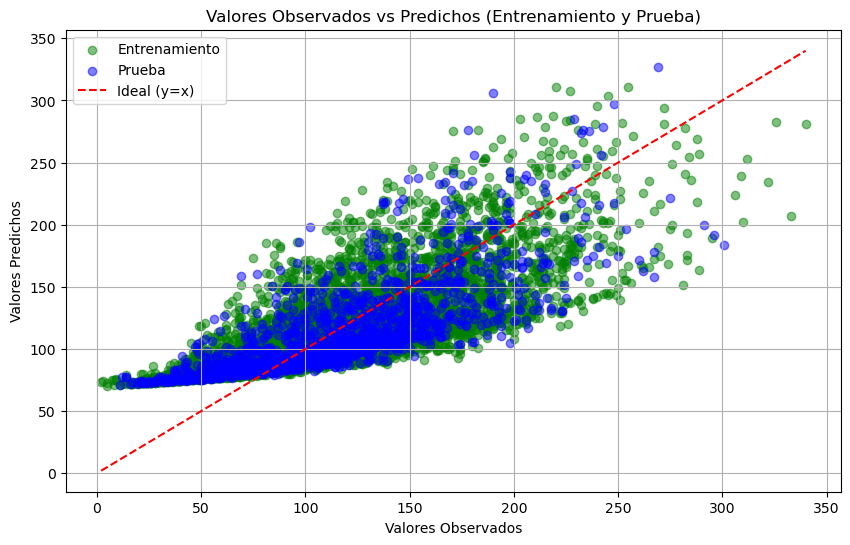

In [21]:
# Desescalar valores de entrenamiento y prueba
Y_train_original = Y_train * scaler.scale_[7] + scaler.mean_[7]
y_train_pred_original = model.predict(X_train) * scaler.scale_[7] + scaler.mean_[7]

Y_test_original =Y_test * scaler.scale_[7] + scaler.mean_[7]
y_test_pred_original = y_pred * scaler.scale_[7] + scaler.mean_[7]

# Crear el gráfico
plt.figure(figsize=(10, 6))

# Graficar valores de entrenamiento
plt.scatter(Y_train_original, y_train_pred_original, color='green', alpha=0.5, label="Entrenamiento")
# Graficar valores de prueba
plt.scatter(Y_test_original, y_test_pred_original, color='blue', alpha=0.5, label="Prueba")
# Línea ideal (y=x)
plt.plot([min(Y_train_original.min(), Y_test_original.min()), 
          max(Y_train_original.max(), Y_test_original.max())], 
         [min(Y_train_original.min(), Y_test_original.min()), 
          max(Y_train_original.max(), Y_test_original.max())], 
         color='red', linestyle='--', label="Ideal (y=x)")

# Personalización del gráfico
plt.title("Valores Observados vs Predichos (Entrenamiento y Prueba)")
plt.xlabel("Valores Observados")
plt.ylabel("Valores Predichos")
plt.legend()
plt.grid(True)

# Mostrar el gráfico
plt.show()

In [22]:
# ¿Qué error tiene el modelo? Explícalo.
# Cálculo de métricas para el conjunto de entrenamiento
mse_train = mean_squared_error(Y_train_original, y_train_pred_original)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(Y_train_original, y_train_pred_original)
r2_train = r2_score(Y_train_original, y_train_pred_original)

# Cálculo de métricas para el conjunto de prueba
mse_test = mean_squared_error(Y_test_original, y_test_pred_original)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(Y_test_original, y_test_pred_original)
r2_test = r2_score(Y_test_original, y_test_pred_original)

# Mostrar resultados
print("Errores en Entrenamiento:")
print(f"MSE: {mse_train:.2f}, RMSE: {rmse_train:.2f}, MAE: {mae_train:.2f}, R^2: {r2_train:.2f}")
print("Errores en Prueba:")
print(f"MSE: {mse_test:.2f}, RMSE: {rmse_test:.2f}, MAE: {mae_test:.2f}, R^2: {r2_test:.2f}")

Errores en Entrenamiento:
MSE: 810.35, RMSE: 28.47, MAE: 20.36, R^2: 0.58
Errores en Prueba:
MSE: 787.23, RMSE: 28.06, MAE: 20.23, R^2: 0.58


Como he dicho anteriormente, considero el modelo suficiente como una primera aproximación, puesto que estamos midiendo la calidad del aire.
Vemos que la diferencia promedio es de 24.74. 

Si tomamos el Índice de Calidad del Aire (AQI) como referencia para ver la calidad del mismo, y solo tenemos en consideración el NO2, tenemos:

- Buena (0-50). Concentración de NO2 0-53ppb.
- Moderada (51-100). Concentración de NO2 54-100ppb.
- No saludable para grupos sensibles (101-150). Concentración de NO2 100-360ppb.
- Insalubre (151-200). Concentración de NO2 361-649ppb.
- Muy insalubre (201-300). Concentración de NO2 650-1249ppb.
- Peligrosa (301-500). Concentración de NO2 1250ppb o más.


Vemos que la diferencia máxima puede implicar (en el caso más restrictivo) empeorar el AQI en un nivel.
Aún así, para una candidad de datos elevada como la del modelo si acabamos con una buena representación de la calidad, aunque valor a valor pueda ser diferente (mirar gráfica).
Estos errores pueden ser inaceptables en muchos otros casos, pero para la situación concreta que estamos evaluando puede ser suficiente.
Igualmente, vamos a seguir modelando con otras opciones, ya que puede haber mejores modelizaciones.

### Regresión lineal múltiple

Se entrena un segundo modelo utilizando el conjunto completo de variables predictoras.

In [23]:
#print(Xy_train_xvar_mean) 
X_train_2 = Xy_train.drop(columns=['NO2(GT)'])
X_test_2 =  Xy_test.drop(columns=['NO2(GT)'])
Y_train_2 = Xy_train['NO2(GT)']
Y_test_2 = Xy_test['NO2(GT)']



# Inicializar el modelo de regresión lineal
model_2 = LinearRegression()
# Entreno modelo
model_2.fit(X_train_2, Y_train_2)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


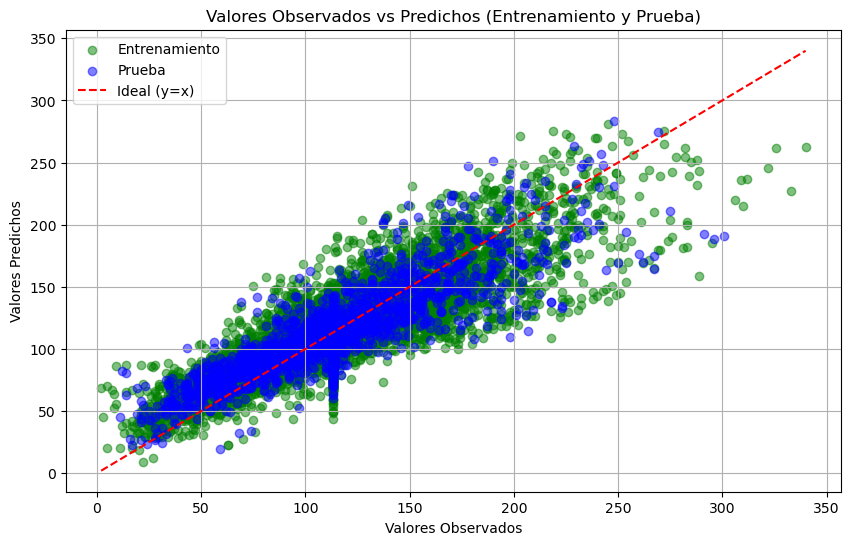

In [24]:
# Hacer predicciones con los datos de prueba
y_pred_2 = model_2.predict(X_test_2)

# Desescalar valores de entrenamiento y prueba
Y_train_2_original = Y_train_2 * scaler.scale_[7] + scaler.mean_[7]
y_train_pred_2_original = model_2.predict(X_train_2) * scaler.scale_[7] + scaler.mean_[7]

Y_test_2_original =Y_test_2 * scaler.scale_[7] + scaler.mean_[7]
y_test_pred_2_original = y_pred_2 * scaler.scale_[7] + scaler.mean_[7]

# Crear el gráfico
plt.figure(figsize=(10, 6))

# Graficar valores de entrenamiento
plt.scatter(Y_train_2_original, y_train_pred_2_original, color='green', alpha=0.5, label="Entrenamiento")
# Graficar valores de prueba
plt.scatter(Y_test_2_original, y_test_pred_2_original, color='blue', alpha=0.5, label="Prueba")
# Línea ideal (y=x)
plt.plot([min(Y_train_2_original.min(), Y_test_2_original.min()), 
          max(Y_train_2_original.max(), Y_test_2_original.max())], 
         [min(Y_train_2_original.min(), Y_test_2_original.min()), 
          max(Y_train_2_original.max(), Y_test_2_original.max())], 
         color='red', linestyle='--', label="Ideal (y=x)")

# Personalización del gráfico
plt.title("Valores Observados vs Predichos (Entrenamiento y Prueba)")
plt.xlabel("Valores Observados")
plt.ylabel("Valores Predichos")
plt.legend()
plt.grid(True)

# Mostrar el gráfico
plt.show()


¿Qué error tiene este modelo?¿Es mejor o peor que el anterior?

In [25]:
# Cálculo de métricas para el conjunto de entrenamiento
mse_train_2 = mean_squared_error(Y_train_2_original, y_train_pred_2_original)
rmse_train_2 = np.sqrt(mse_train_2)
mae_train_2 = mean_absolute_error(Y_train_2_original, y_train_pred_2_original)
r2_train_2 = r2_score(Y_train_2_original, y_train_pred_2_original)

# Cálculo de métricas para el conjunto de prueba
mse_test_2 = mean_squared_error(Y_test_2_original, y_test_pred_2_original)
rmse_test_2 = np.sqrt(mse_test_2)
mae_test_2 = mean_absolute_error(Y_test_2_original, y_test_pred_2_original)
r2_test_2 = r2_score(Y_test_2_original, y_test_pred_2_original)

# Mostrar resultados
print("Errores en Entrenamiento:")
print(f"MSE: {mse_train_2:.2f}, RMSE: {rmse_train_2:.2f}, MAE: {mae_train_2:.2f}, R^2: {r2_train_2:.2f}")
print("Errores en Prueba:")
print(f"MSE: {mse_test_2:.2f}, RMSE: {rmse_test_2:.2f}, MAE: {mae_test_2:.2f}, R^2: {r2_test_2:.2f}")

Errores en Entrenamiento:
MSE: 519.81, RMSE: 22.80, MAE: 17.23, R^2: 0.73
Errores en Prueba:
MSE: 484.48, RMSE: 22.01, MAE: 16.44, R^2: 0.74


Vemos que el R2 ha aumentado, lo cual implica que el modelo es mejor.

Esto se ve también en el resto de variables. Se puede entonces ver que este modelo estima mejor que el otro.

## Regresión con árboles de decisión

Se entrenan modelos basados en `DecisionTreeRegressor` y se analizan los principales hiperparámetros:

* criterion
* splitter
* max_depth
* min_samples_split
* min_samples_leaf
* max_features

Indica qué son cada uno de estos hiperparámetros

- criterion: Define la función de calidad para dividir los nodos del árbol. En regresión las opciones son:
    - MSE (Error cuadrático medio): Criterio por defecto. El objetivo es minimizar la suma de los errores cuadráticos.
    - friedman_mse: Una variante optimizada de MSE.
    - MAE (Error Absoluto Medio): Alternativa que busca minimizar la suma de los errores absolutos.
    - Poisson: Se utiliza cuando se desea aplicar el criterio de Poisson. Es especialmente útil cuando los datos representan conteos.
- splitter: Define el método utilizado para dividir un nodo en subnodos. Las opciones son:
    - Best: Se selecciona la mejor división en cada nodo.
    - Random: Se selecciona una división aleatoria entre las mejores opciones. Esto puede ser útil para introducir algo de aleatoriedad y evitar el sobreajuste, aunque suele ser más lento.
- max_depth: Es la profundidad máxima del árbol. Limitar la profundidad del árbol puede prevenir el sobreajuste, ya que un árbol muy profundo puede memorizar los datos de entrenamiento en lugar de generalizar bien a nuevos datos.
- min_samples_split: Define el número minimo de muestras necesarias para dividir un nodo en subnodos. Si el número de muestras es menor que este valor, no se realiza la división y el nodo se convierte en una hoja. Puede ayudar a prevenir el sobreajuste.
- min_samples_leaf: Define el número mínimo de muestras necesarias para estar en un nodo hoja. Si el número de muestras en una hoja es menor que este valor, se desactivará la división de los nodos en ese punto. Un valor alto puede ayudar a prevenir el sobreajuste.
- max_features: Define el número máximo de características que se deben considerar para encontrar la mejor división en cada nodo. 

Además de los hiperparámetros que acabas de descubrir, la implementación de sklearn tiene el hiperparámetro min_impurity_decrease

¿Qué indica ese parámetro? ¿Para qué puede ser útil?

Controla el mínimo descenso en la impureza necesario para que se realice una división en un nodo. Si la reducción de la impureza es menor que este valor, el nodo no se dividirá, y el modelo no creará más subnodos en ese punto, lo que significa que ese nodo se convertirá en una hoja.

Impureza: Medida de cuán "mezclado" o "heterogéneos" son los datos dentro de un nodo.

Puede ser útil para:
- Controlar la complejidad del árbol: puede ser útil para evitar el sobreajuste al reducir el número de particiones.
- Regularización: El árbol tendrá menos nodos y será más fácil de interpretar.
- Eficiencia computacional: Se pueden evitar cálculos innecesarios.


Entrena un modelo de árboles de decisión donde, el criterio para realizar las particiones sea _poisson_, la profundidad máxima de los árboles debe ser 10, el número mínimo de ejemplos para realizar una partición debe ser 10, el número mínimo de ejemplos para considerarlo una hoja debe ser 2, y el número máximo de características deben ser todas.

In [26]:
from sklearn.tree import DecisionTreeRegressor

#El enunciado me pide dos modelos con árboles de decisión. Voy a hacer un modelo de regresión: uno en el que tomaré las variables que había tomado para el de regresión múltiple, y otro en el que tendré en cuenta el día y la fecha.

In [27]:
## MODELO 1

# Hay que hacer una nueva muestra, porque para este modelo no hay que estandarizar
Xy_train_test_tree = data_num.copy()
Xy_train_test_tree= Xy_train_test_tree.drop(columns=['Date', 'Time'])

Xy_train_tree, Xy_test_tree = train_test_split(Xy_train_test_tree, test_size=0.2, random_state=42)

X_train_tree = Xy_train_tree.drop(columns=['NO2(GT)'])
X_test_tree = Xy_test_tree.drop(columns=['NO2(GT)'])
Y_train_tree = Xy_train_tree['NO2(GT)']
Y_test_tree = Xy_test_tree['NO2(GT)']

# Inicializar el modelo de árboles de decisión con los parámetros especificados
model_tree = DecisionTreeRegressor(
    criterion='poisson',
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features=None,  # Usar todas las características
    random_state=42
)

# Entrenar el modelo
model_tree.fit(X_train_tree, Y_train_tree)

# Hacer predicciones en el conjunto de prueba y el de entreno
y_test_pred_tree = model_tree.predict(X_test_tree)
y_train_pred_tree = model_tree.predict(X_train_tree)



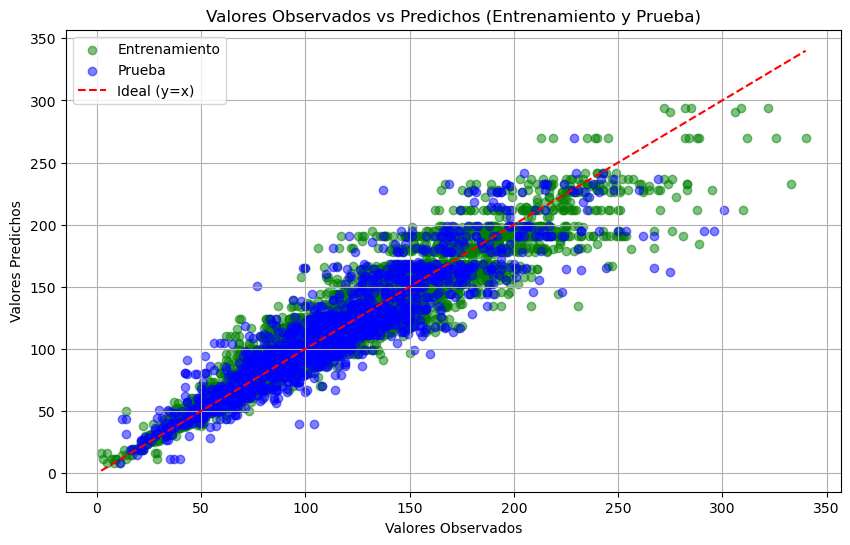

In [28]:
# Crear el gráfico
plt.figure(figsize=(10, 6))

# Graficar valores de entrenamiento
plt.scatter(Y_train_tree, y_train_pred_tree, color='green', alpha=0.5, label="Entrenamiento")
# Graficar valores de prueba
plt.scatter(Y_test_tree,y_test_pred_tree, color='blue', alpha=0.5, label="Prueba")
# Línea ideal (y=x)
plt.plot([min(Y_train_tree.min(), Y_test_tree.min()), 
          max(Y_train_tree.max(), Y_test_tree.max())], 
         [min(Y_train_tree.min(), Y_test_tree.min()), 
          max(Y_train_tree.max(), Y_test_tree.max())], 
         color='red', linestyle='--', label="Ideal (y=x)")

# Personalización del gráfico
plt.title("Valores Observados vs Predichos (Entrenamiento y Prueba)")
plt.xlabel("Valores Observados")
plt.ylabel("Valores Predichos")
plt.legend()
plt.grid(True)

# Mostrar el gráfico
plt.show()


Calcula MAE, R2 y RMSLE

In [29]:
# Cálculo de métricas para el conjunto de entrenamiento
mse_train_tree = mean_squared_error(Y_train_tree, y_train_pred_tree)
rmse_train_tree = np.sqrt(mse_train_tree)
mae_train_tree = mean_absolute_error(Y_train_tree, y_train_pred_tree)
r2_train_tree = r2_score(Y_train_tree, y_train_pred_tree)

#RMSLE
# Calcular el logaritmo de los valores reales y predichos
log_true_train = np.log1p(Y_train_tree)
log_pred_train= np.log1p(y_train_pred_tree)
    
# Calcular las diferencias cuadradas
squared_diff_train = (log_true_train - log_pred_train) ** 2
    
# Calcular la media de las diferencias cuadradas
mean_squared_diff_train = np.mean(squared_diff_train)
    
# Calcular el RMSLE
rmsle_value_train = np.sqrt(mean_squared_diff_train)



# Cálculo de métricas para el conjunto de prueba
mse_test_tree = mean_squared_error(Y_test_tree,y_test_pred_tree)
rmse_test_tree = np.sqrt(mse_test_tree)
mae_test_tree = mean_absolute_error(Y_test_tree, y_test_pred_tree)
r2_test_tree = r2_score(Y_test_tree, y_test_pred_tree)



#RMSLE
# Calcular el logaritmo de los valores reales y predichos
log_true_test = np.log1p(Y_test_tree)
log_pred_test = np.log1p(y_test_pred_tree)
    
# Calcular las diferencias cuadradas
squared_diff_test = (log_true_test - log_pred_test) ** 2
    
# Calcular la media de las diferencias cuadradas
mean_squared_diff_test = np.mean(squared_diff_test)
    
# Calcular el RMSLE
rmsle_value_test = np.sqrt(mean_squared_diff_test)





# Mostrar resultados
print("Errores en Entrenamiento:")
print(f"MSE: {mse_train_tree:.2f}, RMSE: {rmse_train_tree:.2f}, MAE: {mae_train_tree:.2f}, R^2: {r2_train_tree:.2f}, RMSLE: {rmsle_value_train:.2f}")
print("Errores en Prueba:")
print(f"MSE: {mse_test_tree:.2f}, RMSE: {rmse_test_tree:.2f}, MAE: {mae_test_tree:.2f}, R^2: {r2_test_tree:.2f}, RMSLE: {rmsle_value_test:.2f}")

Errores en Entrenamiento:
MSE: 182.73, RMSE: 13.52, MAE: 8.37, R^2: 0.91, RMSLE: 0.11
Errores en Prueba:
MSE: 311.20, RMSE: 17.64, MAE: 11.60, R^2: 0.83, RMSLE: 0.16


### Análisis del sobreajuste

El overfitting ocurre cuando un modelo se ajusta demasiado bien a los datos de entrenamiento, capturando el ruido y las fluctuaciones aleatorias, lo que resulta en un rendimiento pobre en datos nuevos o no vistos (datos de prueba). Esto generalmente se manifiesta cuando hay una gran diferencia entre el rendimiento del modelo en el conjunto de entrenamiento y el conjunto de prueba.
Para ver si hay overfitting, basta con evaluar el rendimiento del mismo en el entrenamiento respecto a la prueba. Para eso podemos comparar las métricas de rendimiento.

Se puede considerar que hay un ligero overfitting, sin embargo, sigo considerando el modelo bueno. El modelo funciona bien para el entrenamiento, y aunque funciona peor para el test, sigue arrojando buenos resultados (de momento es el modelo que mejor resultados tiene).
Para comprobarlo hay que analizar los errores.

In [30]:
## MODELO 2

# Hay que hacer una nueva muestra, porque para este modelo no hay que estandarizar
Xy_train_test_tree_2 = data_num.copy()

Xy_train_tree_2, Xy_test_tree_2 = train_test_split(Xy_train_test_tree_2, test_size=0.2, random_state=42)

X_train_tree_2 = Xy_train_tree_2.drop(columns=['NO2(GT)'])
X_test_tree_2 = Xy_test_tree_2.drop(columns=['NO2(GT)'])
Y_train_tree_2 = Xy_train_tree_2['NO2(GT)']
Y_test_tree_2 = Xy_test_tree_2['NO2(GT)']

# Inicializar el modelo de árboles de decisión con los parámetros especificados
model_tree_2 = DecisionTreeRegressor(
    criterion='poisson',
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features=None,  # Usar todas las características
    random_state=42
)

# Entrenar el modelo
model_tree_2.fit(X_train_tree_2, Y_train_tree_2)

# Hacer predicciones en el conjunto de prueba y el de entreno
y_test_pred_tree_2 = model_tree_2.predict(X_test_tree_2)
y_train_pred_tree_2 = model_tree_2.predict(X_train_tree_2)


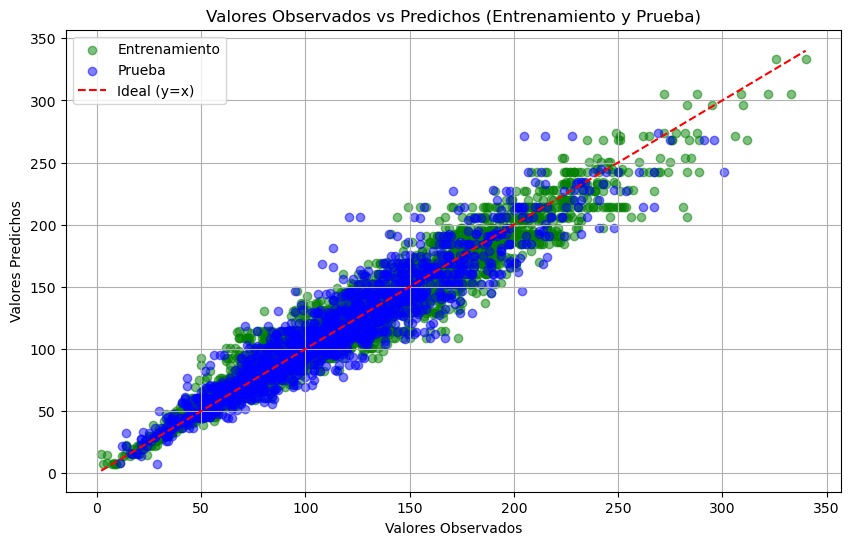

In [31]:
# Crear el gráfico
plt.figure(figsize=(10, 6))

# Graficar valores de entrenamiento
plt.scatter(Y_train_tree_2, y_train_pred_tree_2, color='green', alpha=0.5, label="Entrenamiento")
# Graficar valores de prueba
plt.scatter(Y_test_tree_2,y_test_pred_tree_2, color='blue', alpha=0.5, label="Prueba")
# Línea ideal (y=x)
plt.plot([min(Y_train_tree_2.min(), Y_test_tree_2.min()), 
          max(Y_train_tree_2.max(), Y_test_tree_2.max())], 
         [min(Y_train_tree_2.min(), Y_test_tree_2.min()), 
          max(Y_train_tree_2.max(), Y_test_tree_2.max())], 
         color='red', linestyle='--', label="Ideal (y=x)")

# Personalización del gráfico
plt.title("Valores Observados vs Predichos (Entrenamiento y Prueba)")
plt.xlabel("Valores Observados")
plt.ylabel("Valores Predichos")
plt.legend()
plt.grid(True)

# Mostrar el gráfico
plt.show()

Calcula MAE, R2 y RMSLE

In [32]:
# Cálculo de métricas para el conjunto de entrenamiento
mse_train_tree_2 = mean_squared_error(Y_train_tree_2, y_train_pred_tree_2)
rmse_train_tree_2 = np.sqrt(mse_train_tree_2)
mae_train_tree_2 = mean_absolute_error(Y_train_tree_2, y_train_pred_tree_2)
r2_train_tree_2 = r2_score(Y_train_tree_2, y_train_pred_tree_2)

#RMSLE
# Calcular el logaritmo de los valores reales y predichos
log_true_train_2 = np.log1p(Y_train_tree_2)
log_pred_train_2= np.log1p(y_train_pred_tree_2)
    
# Calcular las diferencias cuadradas
squared_diff_train_2 = (log_true_train_2 - log_pred_train_2) ** 2
    
# Calcular la media de las diferencias cuadradas
mean_squared_diff_train_2 = np.mean(squared_diff_train_2)
    
# Calcular el RMSLE
rmsle_value_train_2 = np.sqrt(mean_squared_diff_train_2)


# Cálculo de métricas para el conjunto de prueba
mse_test_tree_2 = mean_squared_error(Y_test_tree_2,y_test_pred_tree_2)
rmse_test_tree_2 = np.sqrt(mse_test_tree_2)
mae_test_tree_2 = mean_absolute_error(Y_test_tree_2, y_test_pred_tree_2)
r2_test_tree_2 = r2_score(Y_test_tree_2, y_test_pred_tree_2)

#RMSLE
# Calcular el logaritmo de los valores reales y predichos
log_true_test_2 = np.log1p(Y_test_tree_2)
log_pred_test_2 = np.log1p(y_test_pred_tree_2)
    
# Calcular las diferencias cuadradas
squared_diff_test_2 = (log_true_test_2 - log_pred_test_2) ** 2
    
# Calcular la media de las diferencias cuadradas
mean_squared_diff_test_2 = np.mean(squared_diff_test_2)
    
# Calcular el RMSLE
rmsle_value_test_2 = np.sqrt(mean_squared_diff_test_2)


# Mostrar resultados
print("Errores en Entrenamiento:")
print(f"MSE: {mse_train_tree_2:.2f}, RMSE: {rmse_train_tree_2:.2f}, MAE: {mae_train_tree_2:.2f}, R^2: {r2_train_tree_2:.2f}, RMSLE: {rmsle_value_train_2:.2f}")
print("Errores en Prueba:")
print(f"MSE: {mse_test_tree_2:.2f}, RMSE: {rmse_test_tree_2:.2f}, MAE: {mae_test_tree_2:.2f}, R^2: {r2_test_tree_2:.2f}, RMSLE: {rmsle_value_test_2:.2f}")

Errores en Entrenamiento:
MSE: 108.62, RMSE: 10.42, MAE: 6.61, R^2: 0.94, RMSLE: 0.09
Errores en Prueba:
MSE: 208.17, RMSE: 14.43, MAE: 9.63, R^2: 0.89, RMSLE: 0.13


Vemos que este segundo árbol de regresión es ligeramente superior al anterior. Además, disminuye también ligeramente el overfitting.

¿Este modelo es mejor, peor o igual que los de regresión lineal simple y múltiple? Razona tu respuesta.

Revisando las métricas de rendimiento, vemos que el modelo de árbol de decisión es el que mejor ajusta. 

**Comparativa**

En base al EDA realizado, a las decisiones tomadas sobre los datos e hiperparámetros y a las características computacionales de tu equipo. ¿Qué modelo obtiene mejores resultados de regresión?

In [33]:
import time
import tracemalloc

name = "Regresión lineal con una variable"
# Modelo 1
model=LinearRegression()
# Medir el tiempo de entrenamiento
start_time = time.time()
model.fit(X_train, Y_train)
training_time = time.time() - start_time
    
# Medir el tiempo de predicción
start_time = time.time()
y_pred = model.predict(X_test)
prediction_time = time.time() - start_time
    
# Monitorear el uso de memoria
tracemalloc.start()
model.fit(X_train, Y_train)
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
    
print(f"Modelo: {name}")
print(f"Tiempo de entrenamiento: {training_time:.4f} segundos")
print(f"Tiempo de predicción: {prediction_time:.4f} segundos")
print(f"Coeficiente de determinación (R2): {r2_test:.4f}")
print(f"Uso de memoria: {current / 10**6:.4f} MB (actual), {peak / 10**6:.4f} MB (máximo)")
print("-" * 40)



name = "Regresión lineal con todas las variable"
# Modelo 1
model=LinearRegression()
# Medir el tiempo de entrenamiento
start_time = time.time()
model.fit(X_train_2, Y_train_2)
training_time = time.time() - start_time
    
# Medir el tiempo de predicción
start_time = time.time()
y_pred = model.predict(X_test_2)
prediction_time = time.time() - start_time
    
# Monitorear el uso de memoria
tracemalloc.start()
model.fit(X_train_2, Y_train_2)
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
    
print(f"Modelo: {name}")
print(f"Tiempo de entrenamiento: {training_time:.4f} segundos")
print(f"Tiempo de predicción: {prediction_time:.4f} segundos")
print(f"Coeficiente de determinación (R2): {r2_test_2:.4f}")
print(f"Uso de memoria: {current / 10**6:.4f} MB (actual), {peak / 10**6:.4f} MB (máximo)")
print("-" * 40)

name = "Árbol de decisión 1"
# Modelo 1
model= DecisionTreeRegressor(
    criterion='poisson',
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features=None,  # Usar todas las características
    random_state=42
)

# Medir el tiempo de entrenamiento
start_time = time.time()
model.fit(X_train_tree, Y_train_tree)
training_time = time.time() - start_time
    
# Medir el tiempo de predicción
start_time = time.time()
y_pred = model.predict(X_test_tree)
prediction_time = time.time() - start_time
    
# Monitorear el uso de memoria
tracemalloc.start()
model.fit(X_train_tree, Y_train_tree)
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
    
print(f"Modelo: {name}")
print(f"Tiempo de entrenamiento: {training_time:.4f} segundos")
print(f"Tiempo de predicción: {prediction_time:.4f} segundos")
print(f"Coeficiente de determinación (R2): {r2_test_tree:.4f}")
print(f"Uso de memoria: {current / 10**6:.4f} MB (actual), {peak / 10**6:.4f} MB (máximo)")
print("-" * 40)

name = "Árbol de decisión 2"
# Modelo 2
model= DecisionTreeRegressor(
    criterion='poisson',
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features=None,  # Usar todas las características
    random_state=42
)

# Medir el tiempo de entrenamiento
start_time = time.time()
model.fit(X_train_tree, Y_train_tree)
training_time = time.time() - start_time
    
# Medir el tiempo de predicción
start_time = time.time()
y_pred = model.predict(X_test_tree)
prediction_time = time.time() - start_time
    
# Monitorear el uso de memoria
tracemalloc.start()
model.fit(X_train_tree, Y_train_tree)
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
    
print(f"Modelo: {name}")
print(f"Tiempo de entrenamiento: {training_time:.4f} segundos")
print(f"Tiempo de predicción: {prediction_time:.4f} segundos")
print(f"Coeficiente de determinación (R2): {r2_test_tree_2:.4f}")
print(f"Uso de memoria: {current / 10**6:.4f} MB (actual), {peak / 10**6:.4f} MB (máximo)")
print("-" * 40)

Modelo: Regresión lineal con una variable
Tiempo de entrenamiento: 0.0000 segundos
Tiempo de predicción: 0.0000 segundos
Coeficiente de determinación (R2): 0.5814
Uso de memoria: 0.0637 MB (actual), 0.3052 MB (máximo)
----------------------------------------
Modelo: Regresión lineal con todas las variable
Tiempo de entrenamiento: 0.0000 segundos
Tiempo de predicción: 0.0000 segundos
Coeficiente de determinación (R2): 0.7424
Uso de memoria: 0.0638 MB (actual), 1.5749 MB (máximo)
----------------------------------------
Modelo: Árbol de decisión 1
Tiempo de entrenamiento: 0.0487 segundos
Tiempo de predicción: 0.0010 segundos
Coeficiente de determinación (R2): 0.8345
Uso de memoria: 0.0024 MB (actual), 0.4647 MB (máximo)
----------------------------------------
Modelo: Árbol de decisión 2
Tiempo de entrenamiento: 0.0409 segundos
Tiempo de predicción: 0.0000 segundos
Coeficiente de determinación (R2): 0.8893
Uso de memoria: 0.1506 MB (actual), 0.6139 MB (máximo)
---------------------------

Vemos que el árbol de decisión utiliza menos memoria y tarda menos en predecir que el modelo lineal con muchas variables. Además, con él obtenemos mejores resultados.
Si es cierto que tarda más que en el modelo de una variable, pero aqui la diferencia en resultados es importante.
Por todo esto, nos quedaríamos con el modelo del árbol de decisión.

## Investigación

Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de regresión empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.

_introduce aquí la referencia APA del artículo_

Mello, J.D. y Hernández, A.(2019). Un estudio sobre el rendimiento académico en Matemáticas. Revista Electrónica deInvestigación Educativa, 21, e29, 1-10.doi:10.24320/redie.2019.21.e29.2090

título, autores, revista, año de publicación

- Título: Un estudio sobre el rendimiento académico en Matemáticas
- Autores: Jorge Daniel Mello Román (1)decanatofacet@unc.edu.py y Adolfo Hernández Estrada (2)adolfher@ucm.es
- Revista: Revista Electrónica de Investigación Educativa
- Año de publicación: 2019

Objetivo: cuál es el objetivo de la investigación, es decir a qué problema real está aplicando la regresión. Técnicas de regresión empleadas y si realiza alguna adaptación. Principales resultados de la aplicación y de la investigación.

- Objetivo:
El   propósito   de   este   trabajo   es   explicar   el   rendimiento   académico   en   Matemáticas   a   partir   de características  individuales  de  los  estudiantes. 
- Técnicas de regresión empleadas:
Se  aplicó  un  cuestionario  a  899 estudiantes  del  tercer  ciclo  de  Educación  Escolar  Básica  de  instituciones  educativas  de  gestión  pública  y privada del distrito de Concepción. Se utilizaron dos técnicas de modelación estadística: Árbol de decisión y Regresión  lineal  múltiple sobre  variables  observables.
- Se realiza adaptación:
Se optó  por  una  cantidad  reducida  de  variables  a  fin  de  garantizar  la  parsimonia  de  los  modelos  a construir. 

- Resultados de la aplicación y la investigación: 
Se  concluye  que  el  rendimiento  académico  en Matemáticas se explica en gran medida por el aprendizaje que logra el estudiante en el contexto del aula, así como por la percepción que tiene de su propia capacidad. Además factores como el nivel educativo de los padres, el apoyo familiar y la motivación intrínseca tienen un impacto significativo en el rendimiento académico, demostrando la utilidad de la regresión para prever y comprender patrones educativos.